# Notebook dedicated to analyze the dE/dx profile of 5 MeV electrons in the SNO+ Scintillator using RAT v8.

In [172]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sn
from matplotlib import font_manager
from matplotlib.ticker import MultipleLocator, ScalarFormatter

# Auxiliar Funtions

In [173]:
def set_ticks(ax, min_mark, maj_mark):
    # ---- X axis ----
    ax.xaxis.set_minor_locator(MultipleLocator(min_mark))
    ax.xaxis.set_major_formatter(ScalarFormatter(maj_mark))

    # ---- X axis Formatter  ----
    formatter = ScalarFormatter()
    formatter.set_useOffset(False)  # avoid inconvenient representation of axis values
    ax.xaxis.set_major_formatter(formatter)

    # ---- Y axis ----
    #ax.yaxis.set_minor_locator(MultipleLocator(5))
    #ax.yaxis.set_major_formatter(ScalarFormatter())

    # ---- Show ticks on all sides ----
    ax.tick_params(which='minor', top=True, bottom=True, left=True, right=True)
    ax.tick_params(which='major', top=True, bottom=True, left=True, right=True)

# Load Data

In [107]:
fdir = 'E:/Data/rat_test/rat_v8/electrons/np_data/'

electron_data = np.load(fdir+'electron_5MeV_data.npz')
energies_e = electron_data['energies']
dEdx = electron_data['dedx_values']

# MPV of dEdx and $\Delta E_e$

- Select very short intervals for the electron kinetic energy and compute the MPV of dEdx
- Plot the dEdx distribution for each $\Delta E_e$

In [178]:
# ===== Plot font settings =====

font_style_title = {'family':'serif', 'weight': 'normal','color':'black','size':13}
font_style_axis= {'family':'serif', 'weight': 'normal','color':'black','size':11}
font_prop = font_manager.FontProperties(family=font_style_axis['family'], weight=font_style_axis['weight'], size=font_style_axis['size'])

# ===== Save plot directory =====
save_path = 'figs/'

### Stopping Power Distribution

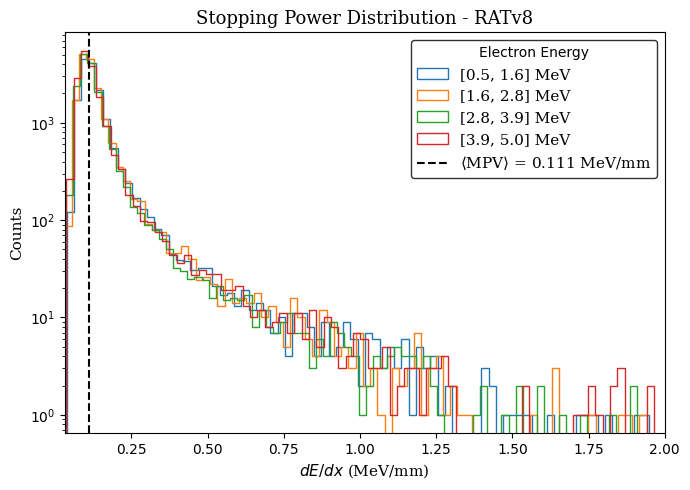

In [179]:
# ==== ΔE_e definition ====
dE_step = 1  # Step of electron energy (MeV) intervals

E_init = 0.5
E_final = 5.0

num_samples = int(round((E_final - E_init) / dE_step)) + 1

E_e_intervals = np.linspace(E_init, E_final, num_samples)
# ===============================

N_intervals = len(E_e_intervals) - 1

MPV_dEdx = []
mean_energy_e = []

fig, ax = plt.subplots(figsize=(7, 5))

for E_i in range(N_intervals):
    En_e_i = E_e_intervals[E_i]
    En_e_f =  E_e_intervals[E_i + 1]
    
    mean_energy_e.append(np.mean(E_e_intervals[E_i : E_i + 1]))

    mask =  (energies_e >= En_e_i) & (energies_e <= En_e_f)
    
    dEdx_inter = dEdx[mask]

    MPV_dEdx.append(np.median(dEdx_inter))
    mean_MPV_dEdx = np.mean(MPV_dEdx)

    # ------ dE/dx distribution plots ------
    bins = 80
    dEdx_sup_cut = 2

    label_str = f"[{En_e_i:.1f}, {En_e_f:.1f}] MeV"

    sn.histplot(dEdx_inter[dEdx_inter < dEdx_sup_cut], bins = bins, element = 'step',
               alpha=0, ax=ax, label=label_str)

ax.axvline(x = mean_MPV_dEdx, label = rf'$\langle$MPV$\rangle$ = {mean_MPV_dEdx:.3f} MeV/mm', color = 'black', ls = '--')

# ======= Axis settings =======

# --- axis limits ---
ax.set_xlim(min(dEdx), dEdx_sup_cut)

# --- axis scales ---
ax.set_yscale('log')

# --- axis titles ---
ax.set_xlabel(r'$dE/dx$ (MeV/mm)', fontdict = font_style_axis )
ax.set_ylabel('Counts', fontdict = font_style_axis)

ax.set_title('Stopping Power Distribution - RATv8', fontdict = font_style_title)

ax.legend(title=r'Electron Energy', loc='best', frameon=True, edgecolor='black', prop=font_prop)

plt.tight_layout() 

plt.savefig(save_path + 'stopping_power', dpi=300, bbox_inches='tight')

plt.show()

### MPV vs. $\Delta E_e$

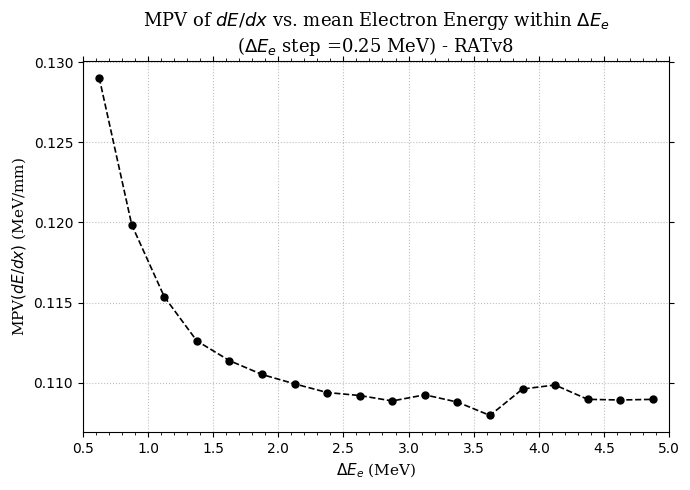

In [180]:
# ==== ΔE_e definition ====
dE_step = 1/4  # Step of electron energy (MeV) intervals

E_init = 0.5
E_final = 5.0

num_samples = int(round((E_final - E_init) / dE_step)) + 1

E_e_intervals = np.linspace(E_init, E_final, num_samples)
# ===============================

N_intervals = len(E_e_intervals) - 1

MPV_dEdx = []
mean_energy_e = []

fig, ax = plt.subplots(figsize=(7, 5))

for E_i in range(N_intervals):
    En_e_i = E_e_intervals[E_i]
    En_e_f =  E_e_intervals[E_i + 1]
    
    mean_energy_e.append((En_e_i + En_e_f) / 2.0)

    mask =  (energies_e >= En_e_i) & (energies_e <= En_e_f)
    
    dEdx_inter = dEdx[mask]

    MPV_dEdx.append(np.median(dEdx_inter))

# ------ MPV(dE/dx) vs ΔE_e plots ------

ax.plot(mean_energy_e, MPV_dEdx, 
        marker='o',          # Marcador circular clásico
        markersize=5,        # Tamaño adecuado para no abrumar la línea
        color='black',       # Color uniforme
        linestyle='--',      # Línea discontinua
        linewidth=1.2,       # Grosor sutil de la línea
        zorder=3)            # Asegura que se dibuje por encima de la cuadrícula

# ======= Axis settings =======

# --- axis markers ---
min_mark = 0.1
maj_mark = 1
set_ticks(ax, min_mark, maj_mark)

# --- axis limits ---
ax.set_xlim(0.5, 5)

# --- axis scales ---
#ax.set_yscale('log')

# --- axis titles ---
ax.set_ylabel(r'MPV$(dE/dx)$ (MeV/mm)', fontdict = font_style_axis )
ax.set_xlabel(r'$\Delta E_e$ (MeV)', fontdict = font_style_axis)

# --- Plot main title ---
ax.set_title(rf'MPV of $dE/dx$ vs. mean Electron Energy within $\Delta E_e$' + '\n' + rf'($\Delta E_e$ step ={dE_step} MeV) - RATv8', fontdict = font_style_title)

ax.grid(True, which='major', color='gray', linestyle=':', alpha=0.5, zorder=0)

plt.tight_layout() 

plt.savefig(save_path + 'MPV_dEdx_vs_mean_energy', dpi=300, bbox_inches='tight')

plt.show()